## **XGBoost Regressor**

### Concept
**XGBoost** builds an ensemble of decision trees to capture non-linear patterns. Unlike statistical models, it learns **threshold-based rules** (e.g., "If Rain > 50mm, Inflow spikes"), making it ideal for predicting sudden reservoir changes.

### Setup
* **Features:** All engineered data (Lags, Rolling Means, Weather).
* **Goal:** Minimize regression error.

**Import Required libraries and Modules**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from xgboost import plot_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error
import sys
import os

**Setup & Data Loading**

In [2]:
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/EDI-III Project/Data/Processed Data'
else:
    BASE_PATH = '.'

# Load the processed Chembarambakkam dataset
file_path = os.path.join(BASE_PATH, 'Chembarambakkam.csv')
print(f"Loading data from: {file_path}")

try:
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

    if df.index.duplicated().any():
        print(f"Warning: Found {df.index.duplicated().sum()} duplicate dates. Keeping the first occurrence.")
        df = df[~df.index.duplicated(keep='first')]

    df = df.asfreq('D')

    df = df.ffill()
except FileNotFoundError:
    print("Error: File not found. Please run the Data Processing script first.")
    sys.exit()

Mounted at /content/drive
Loading data from: /content/drive/MyDrive/EDI-III Project/Data/Processed Data/Chembarambakkam.csv


**Feature Selection**

In [3]:
features = [
    'Rainfall (mm)', 'Inflow (cusecs)',
    'Rainfall_Lag1', 'Inflow_Lag1', 'Storage_Lag1',
    'Rainfall_Lag2', 'Inflow_Lag2', 'Storage_Lag2',
    'Rainfall_Lag3', 'Inflow_Lag3', 'Storage_Lag3',
    'Rainfall_RollMean_7d', 'Inflow_RollMean_7d',
    'Month', 'DayOfYear'
]
target = 'Storage (mcft)'

**Time Series Split Data**

In [4]:
# Using the same 730-day (2 year) test set for fair comparison
test_days = 730

train = df.iloc[:-test_days]
test = df.iloc[-test_days:]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print(f"Training Shape: {X_train.shape}")
print(f"Testing Shape: {X_test.shape}")

Training Shape: (6812, 15)
Testing Shape: (730, 15)


**Build and Train Model**

In [5]:
print("\nTraining XGBoost Regressor...")
model = xgb.XGBRegressor(
    n_estimators=1000,      # Number of trees (boosting rounds)
    learning_rate=0.01,     # Step size shrinkage to prevent overfitting
    max_depth=6,            # Depth of trees
    early_stopping_rounds=50, # Stop if validation score doesn't improve
    random_state=42,
    n_jobs=-1               # Use all CPU cores
)

# We use the test set as the "eval_set" to monitor performance during training
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100  # Print progress every 100 rounds
)


Training XGBoost Regressor...
[0]	validation_0-rmse:1025.28888	validation_1-rmse:1315.26838
[100]	validation_0-rmse:383.52535	validation_1-rmse:490.11880
[200]	validation_0-rmse:152.85708	validation_1-rmse:188.22891
[300]	validation_0-rmse:73.30090	validation_1-rmse:82.88380
[400]	validation_0-rmse:47.45425	validation_1-rmse:53.52153
[500]	validation_0-rmse:38.59463	validation_1-rmse:49.68538
[600]	validation_0-rmse:33.78553	validation_1-rmse:48.73080
[700]	validation_0-rmse:28.85454	validation_1-rmse:48.68383
[717]	validation_0-rmse:28.18079	validation_1-rmse:49.24724


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=-1, num_parallel_tree=None, ...)

**Prediction and Evaluation**

In [7]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# --- Generate Predictions ---
predictions = model.predict(X_test)

# --- Evaluation Metrics ---

# 1. RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

# 2. MAE (Mean Absolute Error)
mae = mean_absolute_error(y_test, predictions)

# 3. MAPE (Mean Absolute Percentage Error)
# We add a tiny epsilon (1e-10) to actuals to avoid division by zero errors
mape = np.mean(np.abs((y_test - predictions) / (y_test + 1e-10))) * 100

# 4. R-squared (R2)
r2 = r2_score(y_test, predictions)

# --- Print Results ---
print(f"\n{'='*30}")
print(f"XGBoost EVALUATION")
print(f"{'='*30}")
print(f"RMSE : {rmse:.2f} mcft")
print(f"MAE  : {mae:.2f} mcft")
print(f"MAPE : {mape:.2f} %")
print(f"R²   : {r2:.4f}")
print(f"{'='*30}")


XGBoost EVALUATION
RMSE : 48.37 mcft
MAE  : 17.31 mcft
MAPE : 0.62 %
R²   : 0.9923


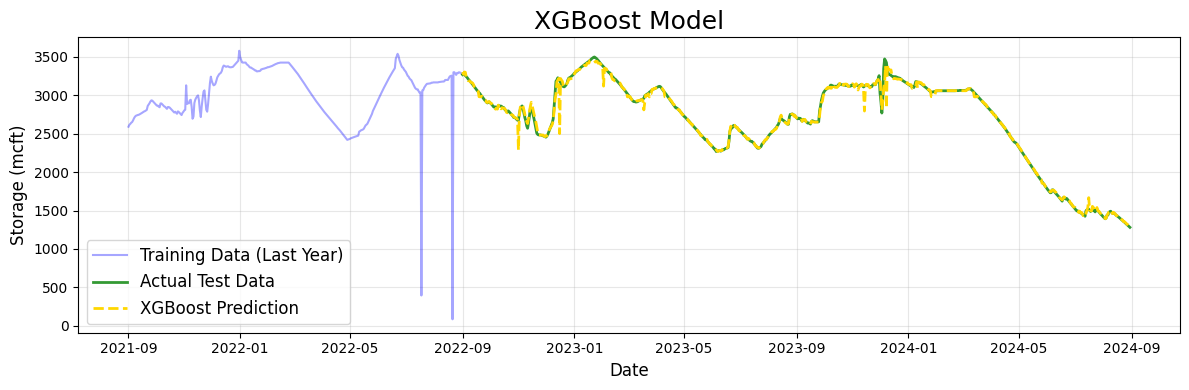

In [8]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plt.figure(figsize=(12, 4))

if len(train) > 365:
    plot_start_date = train.index[-365]
    subset_train = train.loc[train.index >= plot_start_date]
else:
    subset_train = train

plt.plot(
    subset_train.index,
    subset_train[target],
    label="Training Data (Last Year)",
    color="blue",
    alpha=0.35
)

# Actual test values
plt.plot(
    test.index,
    y_test,
    label="Actual Test Data",
    color="green",
    linewidth=2,
    alpha=0.8
)

# Using 'predictions' from the evaluation cell
plt.plot(
    test.index,
    predictions,
    label="XGBoost Prediction",
    color="gold",
    linestyle="--",
    linewidth=2
)

# Using 'rmse' from the evaluation cell
plt.title(f"XGBoost Model", fontsize=18)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Storage (mcft)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

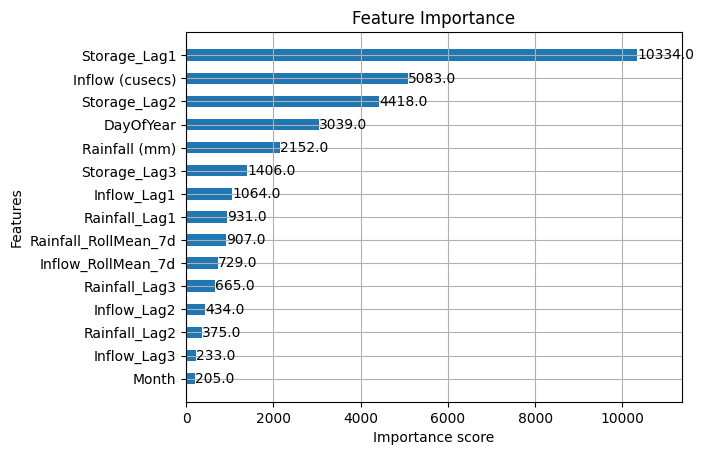

In [9]:
plt.figure(figsize=(10, 8))
plot_importance(model, max_num_features=15, height=0.5)
plt.title('Feature Importance')
plt.show()